# Notebook 06 — Spatial Statistics and Mini Research
## Spatial Autocorrelation of PM₂.₅ Monitoring Stations

**ระดับผู้เรียน:** ปริญญาตรีปี 3–4 / ปริญญาโท  
**กลุ่มสาขา:** สิ่งแวดล้อม ภูมิศาสตร์ ภูมิสารสนเทศ อุตุนิยมวิทยา  
**Platform:** Google Colab

---

# บทสุดท้ายของ Core Course

Notebook 01:

```text
Canonical dataset
```

Notebook 02:

```text
Pandas + PM2.5 QC
```

Notebook 03:

```text
Map + CRS + GeoPandas
```

Notebook 04:

```text
Spatial join + Distance + WMO matching
```

Notebook 05:

```text
Spatiotemporal PM2.5 analysis
```

Notebook 06:

```text
Spatial structure
+
Statistical inference
+
Scientific interpretation
+
Mini research
```

---

# คำถามหลัก

> ในปีที่เลือก ค่าความเข้มข้น PM₂.₅ รายสถานีมีแนวโน้มเกิด spatial clustering หรือไม่?

และถ้ามี:

> สถานีใดมีลักษณะ High–High, Low–Low, High–Low หรือ Low–High?

แต่ก่อนตอบ เราต้องกำหนดว่า:

```text
“neighbor” คือใคร?
```

นี่คือหัวใจของ spatial statistics

# Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

1. อธิบาย First Law of Geography ได้
2. อธิบาย spatial autocorrelation ได้
3. เข้าใจ spatial weights matrix \(W_{ij}\)
4. อธิบาย K-nearest-neighbor weights ได้
5. อธิบาย distance-band weights ได้
6. สร้าง geodesic distance matrix ระหว่างสถานี
7. เลือก temporal slice ที่ไม่ปะปน repeated observations หลายปี
8. ใช้ completeness criterion ก่อน spatial inference
9. ตรวจจำนวน neighbors ของแต่ละสถานี
10. วิเคราะห์ sensitivity ต่อ \(k\)
11. คำนวณ Global Moran's I
12. อธิบาย expected Moran's I
13. ใช้ permutation test
14. อ่าน Moran scatterplot
15. คำนวณ Local Moran / LISA
16. จำแนก HH, LL, HL และ LH
17. แยก local cluster จาก global autocorrelation
18. เข้าใจปัญหา multiple testing ของ LISA
19. ใช้ Benjamini–Hochberg FDR correction
20. สร้าง LISA station map
21. เปรียบเทียบ KNN กับ distance-band weights
22. อธิบาย sensitivity ต่อ spatial weights
23. เข้าใจข้อจำกัดจาก sparse/uneven monitoring network
24. เข้าใจว่า station LISA ไม่ใช่ continuous hotspot surface
25. สรุป mini research อย่าง reproducible

# 6.1 Tobler's First Law of Geography

แนวคิดพื้นฐานที่มีชื่อเสียง:

> สิ่งทุกสิ่งสัมพันธ์กับสิ่งอื่น แต่สิ่งที่อยู่ใกล้กันมักสัมพันธ์กันมากกว่า

ในงาน PM₂.₅:

สถานีที่อยู่ใกล้กันอาจได้รับอิทธิพลร่วมจาก:

```text
regional transport
meteorological conditions
emission regions
boundary-layer structure
biomass burning
topography
```

ดังนั้นค่าที่สถานีใกล้กันอาจคล้ายกันมากกว่าค่าที่อยู่ไกลกัน

แต่:

> spatial similarity ไม่ได้พิสูจน์สาเหตุ

# 6.2 Spatial Autocorrelation

Spatial autocorrelation ถามว่า:

> ค่าในตำแหน่งใกล้เคียงกันมีความคล้ายหรือแตกต่างกันอย่างเป็นระบบหรือไม่?

แนวคิดเชิงคุณภาพ:

```text
Positive spatial autocorrelation
High near High
Low near Low

Negative spatial autocorrelation
High near Low
Low near High

No clear spatial autocorrelation
pattern ใกล้ random
```

Global Moran's I เป็นสถิติที่ใช้วัดแนวโน้มระดับทั้ง network

# 6.3 Spatial Weights Matrix \(W\)

Spatial statistics ต้องนิยามความเป็นเพื่อนบ้านก่อน

เขียนเป็น:

\[
W_{ij}
\]

โดย:

```text
W_ij = น้ำหนักความสัมพันธ์ระหว่าง location i และ j
```

ตัวอย่าง:

```text
W_ij = 1 ถ้า j เป็น 6 nearest neighbors ของ i
W_ij = 0 ถ้าไม่ใช่
```

หรือ:

```text
W_ij = 1 ถ้าระยะทาง <= threshold
```

---

# ประเด็นสำคัญ

ผล Moran's I และ LISA ไม่ได้ขึ้นกับข้อมูล PM₂.₅ อย่างเดียว

แต่ขึ้นกับ:

```text
PM2.5 values
+
spatial weights definition
```

ดังนั้นต้องทำ sensitivity analysis

# 6.4 Temporal Independence Problem

ข้อมูล Notebook 05 มีหลายปี:

```text
station A — 2021
station A — 2022
station A — 2023
...
```

ถ้านำทุก station-year มาเป็น spatial observations พร้อมกัน:

```text
location เดิมซ้ำหลายครั้ง
```

และ observations มี temporal dependence

จึงไม่เหมาะที่จะถือว่าเป็น spatially independent locations

---

# หลักของ Notebook นี้

เลือก:

```text
หนึ่งปี
หนึ่งค่าต่อสถานี
```

เช่น:

```text
station-year mean PM2.5
```

แล้วทำ spatial statistics บน temporal slice เดียว

In [1]:
# CELL 1 — Install spatial-statistics packages

!pip -q install -U \
    pandas \
    geopandas \
    pyogrio \
    shapely \
    pyproj \
    scikit-learn \
    libpysal \
    esda \
    pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [2]:
# CELL 2 — Mount Google Drive

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [3]:
# CELL 3 — Imports

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import haversine_distances

from libpysal.weights import W
from libpysal.weights.spatial_lag import lag_spatial

from esda.moran import Moran
from esda.moran import Moran_Local

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning
)

print(
    "pandas:",
    pd.__version__
)

print(
    "GeoPandas:",
    gpd.__version__
)

pandas: 3.0.5
GeoPandas: 1.1.4


# 6.5 Input Data

ใช้ผลจาก Notebook 05:

```text
05_spatiotemporal_airquality.gpkg
```

layer:

```text
station_year_pm25
```

มี:

```text
station_id
year
mean_pm25
median_pm25
coverage
geometry
```

และใช้ canonical:

```text
environmental_gis_course.gpkg
```

เพื่ออ่าน province boundaries

In [4]:
# CELL 4 — Paths

DATASET_VERSION = "v1"

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Teaching_PCD_Environmental_GIS"
)

DATASET_DIR = (
    BASE_DIR
    / "01_course_data"
    / DATASET_VERSION
    / "dataset"
)

NOTEBOOK05_OUTPUT = (
    BASE_DIR
    / "02_output"
    / "Notebook_05"
)

OUTPUT_DIR = (
    BASE_DIR
    / "02_output"
    / "Notebook_06"
)

FIGURE_DIR = (
    BASE_DIR
    / "03_figures"
    / "Notebook_06"
)

for folder in [
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print(
    "Notebook 06 output:"
)

print(
    OUTPUT_DIR
)

Notebook 06 output:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_06


In [5]:
# CELL 5 — File locator

def find_unique_file(
    root,
    filename,
    required=True,
):
    root = Path(
        root
    )

    if not root.exists():

        if required:

            raise FileNotFoundError(
                f"Folder not found: {root}"
            )

        return None

    matches = list(
        root.rglob(
            filename
        )
    )

    if len(
        matches
    ) == 1:

        return matches[
            0
        ]

    if len(
        matches
    ) == 0:

        if required:

            raise FileNotFoundError(
                f"Required file not found: {filename}"
            )

        return None

    raise RuntimeError(
        f"Multiple copies found for {filename}: "
        + str(
            matches
        )
    )


COURSE_GPKG = find_unique_file(
    DATASET_DIR,
    "environmental_gis_course.gpkg",
)

SPATIOTEMPORAL_GPKG = find_unique_file(
    NOTEBOOK05_OUTPUT,
    "05_spatiotemporal_airquality.gpkg",
)

STATION_YEAR_CSV = find_unique_file(
    NOTEBOOK05_OUTPUT,
    "05_station_year_PM25.csv",
    required=False,
)


print(
    "Course GeoPackage:"
)

print(
    COURSE_GPKG
)

print(
    "\nNotebook 05 GeoPackage:"
)

print(
    SPATIOTEMPORAL_GPKG
)

Course GeoPackage:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset/processed/environmental_gis_course.gpkg

Notebook 05 GeoPackage:
/content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_05/05_spatiotemporal_airquality.gpkg


In [6]:
# CELL 6 — Read station-year PM2.5 and province boundaries

province = gpd.read_file(
    COURSE_GPKG,
    layer="province",
)

station_year = gpd.read_file(
    SPATIOTEMPORAL_GPKG,
    layer="station_year_pm25",
)


station_year[
    "station_id"
] = (
    station_year[
        "station_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.lower()
)


station_year[
    "year"
] = pd.to_numeric(
    station_year[
        "year"
    ],
    errors="coerce",
).astype(
    "Int64"
)


station_year[
    "mean_pm25"
] = pd.to_numeric(
    station_year[
        "mean_pm25"
    ],
    errors="coerce",
)


station_year[
    "calendar_year_coverage_pct"
] = pd.to_numeric(
    station_year[
        "calendar_year_coverage_pct"
    ],
    errors="coerce",
)


print(
    "Station-year rows:",
    len(
        station_year
    )
)

print(
    "Stations:",
    station_year[
        "station_id"
    ].nunique()
)

print(
    "Years:",
    sorted(
        station_year[
            "year"
        ]
        .dropna()
        .astype(int)
        .unique()
    )
)

Station-year rows: 201
Stations: 105
Years: [np.int64(2024), np.int64(2025)]


# 6.6 Analysis Parameters

Spatial statistics ต้องประกาศ parameter อย่างโปร่งใส

Notebook นี้กำหนด:

```text
VARIABLE = mean_pm25

MIN_COVERAGE_PCT = 75

K values = 4, 6, 8

PERMUTATIONS = 999

ALPHA = 0.05

FDR_Q = 0.05
```

---

# Analysis Year

default ไม่ hard-code เป็นปีใดปีหนึ่ง

Notebook จะเลือกปีที่มี:

```text
จำนวน coverage-eligible stations มากที่สุด
```

ถ้าเสมอกัน เลือกปีล่าสุด

นิสิตสามารถเปลี่ยน `ANALYSIS_YEAR`
แล้ว Run ใหม่เพื่อทำ sensitivity analysis

In [7]:
# CELL 7 — Spatial-statistics parameters

VARIABLE = (
    "mean_pm25"
)

MIN_COVERAGE_PCT = 75.0

K_VALUES_REQUESTED = [
    4,
    6,
    8,
]

PRIMARY_K_REQUESTED = 6

PERMUTATIONS = 999

RANDOM_SEED = 42

ALPHA = 0.05

FDR_Q = 0.05

EARTH_RADIUS_KM = (
    6371.0088
)


eligible_counts = (
    station_year[
        station_year[
            "calendar_year_coverage_pct"
        ]
        >= MIN_COVERAGE_PCT
    ]
    .groupby(
        "year"
    )
    .agg(
        eligible_station_n=(
            "station_id",
            "nunique",
        )
    )
    .reset_index()
)


eligible_counts = (
    eligible_counts
    .sort_values(
        [
            "eligible_station_n",
            "year",
        ],
        ascending=[
            False,
            False,
        ],
    )
)


if len(
    eligible_counts
) == 0:

    raise RuntimeError(
        "No station-year record meets "
        "the completeness threshold."
    )


ANALYSIS_YEAR = int(
    eligible_counts[
        "year"
    ]
    .iloc[
        0
    ]
)


print(
    "Default analysis year:",
    ANALYSIS_YEAR
)

display(
    eligible_counts
)

Default analysis year: 2025


,year,eligible_station_n
1,2025,96
0,2024,96


# 6.7 Build One Spatial Cross-Section

เลือก:

```text
year = ANALYSIS_YEAR
coverage >= 75%
PM2.5 non-missing
geometry non-missing
```

และตรวจ:

```text
1 station = 1 row
```

ถ้ามี station ซ้ำ ต้องหยุด เพราะ spatial sample ไม่ถูกต้อง

In [8]:
# CELL 8 — Create analysis slice

analysis_points = (
    station_year[
        station_year[
            "year"
        ]
        .eq(
            ANALYSIS_YEAR
        )
        &
        (
            station_year[
                "calendar_year_coverage_pct"
            ]
            >= MIN_COVERAGE_PCT
        )
        &
        station_year[
            VARIABLE
        ]
        .notna()
        &
        station_year.geometry.notna()
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


duplicate_station_n = int(
    analysis_points[
        "station_id"
    ]
    .duplicated(
        keep=False
    )
    .sum()
)


if duplicate_station_n > 0:

    raise RuntimeError(
        "Duplicate station IDs exist in the analysis slice. "
        "Spatial statistics requires one row per station."
    )


analysis_points = gpd.GeoDataFrame(
    analysis_points,
    geometry="geometry",
    crs=station_year.crs,
)


print(
    "Analysis year:",
    ANALYSIS_YEAR
)

print(
    "Spatial observations:",
    len(
        analysis_points
    )
)

print(
    "CRS:",
    analysis_points.crs
)


if len(
    analysis_points
) < 10:

    print(
        "\nWARNING:"
    )

    print(
        "Fewer than 10 stations are available. "
        "Spatial-statistical inference will be fragile."
    )

Analysis year: 2025
Spatial observations: 94
CRS: EPSG:4326


In [9]:
# CELL 9 — Analysis-slice QC

analysis_qc = pd.DataFrame([
    {
        "check":
            "analysis_year",

        "value":
            ANALYSIS_YEAR,
    },

    {
        "check":
            "station_n",

        "value":
            len(
                analysis_points
            ),
    },

    {
        "check":
            "duplicate_station_rows",

        "value":
            duplicate_station_n,
    },

    {
        "check":
            "minimum_coverage_pct",

        "value":
            analysis_points[
                "calendar_year_coverage_pct"
            ].min(),
    },

    {
        "check":
            "median_coverage_pct",

        "value":
            analysis_points[
                "calendar_year_coverage_pct"
            ].median(),
    },

    {
        "check":
            "PM25_mean",

        "value":
            analysis_points[
                VARIABLE
            ].mean(),
    },

    {
        "check":
            "PM25_median",

        "value":
            analysis_points[
                VARIABLE
            ].median(),
    },

    {
        "check":
            "PM25_min",

        "value":
            analysis_points[
                VARIABLE
            ].min(),
    },

    {
        "check":
            "PM25_max",

        "value":
            analysis_points[
                VARIABLE
            ].max(),
    },
])


display(
    analysis_qc
)

,check,value
0,analysis_year,2025.000000
1,station_n,94.000000
2,duplicate_station_rows,0.000000
3,minimum_coverage_pct,75.890411
4,median_coverage_pct,98.904110
5,PM25_mean,21.460515
6,PM25_median,22.060706
7,PM25_min,9.120286
8,PM25_max,31.995041


# 6.8 Map Before Statistics

ก่อนคำนวณ Moran's I ให้ดูข้อมูลก่อน

คำถาม:

```text
ค่าดู clustered หรือไม่?
station density สม่ำเสมอหรือไม่?
มีพื้นที่ sparse หรือไม่?
มี extreme station หรือไม่?
```

แผนที่นี้เป็น exploratory map
ยังไม่ใช่ผลทดสอบ spatial autocorrelation

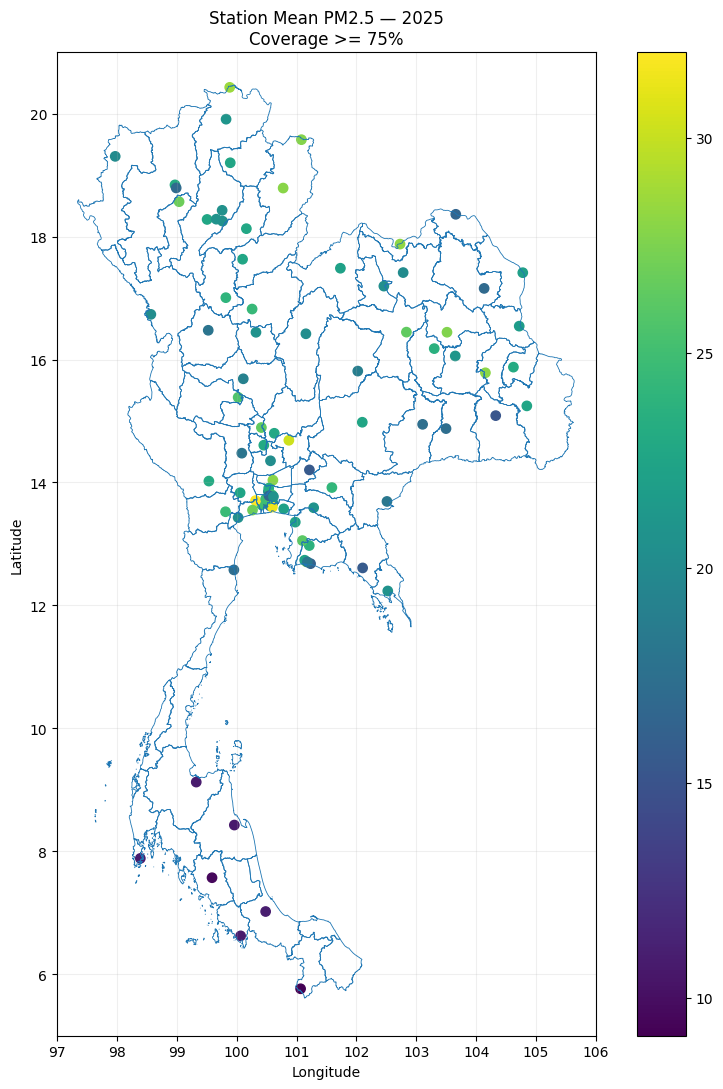

In [10]:
# CELL 10 — Analysis-year station map

fig, ax = plt.subplots(
    figsize=(
        8.5,
        11,
    )
)

province.boundary.plot(
    ax=ax,
    linewidth=0.6,
)

analysis_points.plot(
    ax=ax,
    column=VARIABLE,
    legend=True,
    markersize=45,
)

ax.set_xlim(
    97,
    106,
)

ax.set_ylim(
    5,
    21,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    (
        f"Station Mean PM2.5 — {ANALYSIS_YEAR}\n"
        f"Coverage >= {MIN_COVERAGE_PCT:.0f}%"
    )
)

ax.grid(
    alpha=0.2
)

fig.tight_layout()

RAW_MAP = (
    FIGURE_DIR
    / (
        f"06_analysis_PM25_{ANALYSIS_YEAR}.png"
    )
)

fig.savefig(
    RAW_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 6.9 National Distances: Use Geodesic/Haversine Geometry

ประเทศไทยครอบคลุมมากกว่าหนึ่ง UTM zone

ดังนั้น Notebook นี้จะไม่ใช้ UTM zone เดียวเพื่อสร้าง national spatial weights

เราจะคำนวณ great-circle approximation ด้วย:

```text
Haversine distance
```

จาก:

```text
longitude / latitude
```

หน่วยสุดท้ายเป็น:

```text
km
```

สำหรับ spatial-neighbor topology ระดับประเทศ

In [11]:
# CELL 11 — Coordinates and geodesic distance matrix

analysis_wgs84 = (
    analysis_points
    .to_crs(
        4326
    )
    .copy()
)


analysis_wgs84[
    "longitude"
] = (
    analysis_wgs84.geometry.x
)

analysis_wgs84[
    "latitude"
] = (
    analysis_wgs84.geometry.y
)


coordinate_radians = np.radians(
    analysis_wgs84[
        [
            "latitude",
            "longitude",
        ]
    ]
    .to_numpy(
        dtype=float
    )
)


distance_matrix_km = (
    haversine_distances(
        coordinate_radians
    )
    * EARTH_RADIUS_KM
)


np.fill_diagonal(
    distance_matrix_km,
    np.inf,
)


print(
    "Distance matrix shape:",
    distance_matrix_km.shape
)

print(
    "Nearest-neighbor distance range:"
)

nearest_distances = (
    distance_matrix_km.min(
        axis=1
    )
)

print(
    "min:",
    nearest_distances.min(),
    "km"
)

print(
    "median:",
    np.median(
        nearest_distances
    ),
    "km"
)

print(
    "max:",
    nearest_distances.max(),
    "km"
)

Distance matrix shape: (94, 94)
Nearest-neighbor distance range:
min: 0.5927812519252526 km
median: 40.955564125823884 km
max: 146.37649927947882 km


# 6.10 Build KNN Weights from the Geodesic Distance Matrix

สำหรับแต่ละ station:

```text
เรียงระยะทาง
เลือก k สถานีที่ใกล้ที่สุด
```

แล้วสร้าง:

```text
neighbors dictionary
```

ก่อนแปลงเป็น `libpysal.weights.W`

---

# Row Standardization

กำหนด:

```python
w.transform = "R"
```

หมายความว่า weights ของ neighbors ในแต่ละ row รวมกันเป็น 1

นี่ทำให้ spatial lag ตีความคล้าย:

> ค่าเฉลี่ยถ่วงน้ำหนักของเพื่อนบ้าน

In [12]:
# CELL 12 — Spatial-weight helper functions

def build_knn_w(
    ids,
    distance_matrix,
    k,
):
    n = len(
        ids
    )

    if n < 2:

        raise ValueError(
            "At least two spatial observations are required."
        )

    k_effective = min(
        int(
            k
        ),
        n - 1,
    )

    neighbors = {}

    weights = {}

    for i, station_id in enumerate(
        ids
    ):

        nearest_positions = (
            np.argsort(
                distance_matrix[
                    i
                ]
            )[
                :k_effective
            ]
        )

        neighbors[
            station_id
        ] = [
            ids[
                j
            ]
            for j
            in nearest_positions
        ]

        weights[
            station_id
        ] = [
            1.0
            for _
            in nearest_positions
        ]


    w = W(
        neighbors=
            neighbors,

        weights=
            weights,

        ids=
            ids,

        silence_warnings=
            True,
    )

    w.transform = "R"

    return (
        w,
        k_effective,
    )


def build_distance_band_w(
    ids,
    distance_matrix,
    threshold_km,
):
    neighbors = {}

    weights = {}


    for i, station_id in enumerate(
        ids
    ):

        neighbor_positions = np.where(
            distance_matrix[
                i
            ]
            <= threshold_km
        )[
            0
        ]

        neighbors[
            station_id
        ] = [
            ids[
                j
            ]
            for j
            in neighbor_positions
        ]

        weights[
            station_id
        ] = [
            1.0
            for _
            in neighbor_positions
        ]


    w = W(
        neighbors=
            neighbors,

        weights=
            weights,

        ids=
            ids,

        silence_warnings=
            True,
    )

    w.transform = "R"

    return w


def weights_summary(
    w,
    label,
):
    cardinalities = np.array(
        list(
            w.cardinalities.values()
        ),
        dtype=float,
    )

    return {
        "weights":
            label,

        "n":
            w.n,

        "islands_n":
            len(
                w.islands
            ),

        "neighbors_min":
            cardinalities.min()
            if len(
                cardinalities
            )
            else np.nan,

        "neighbors_mean":
            cardinalities.mean()
            if len(
                cardinalities
            )
            else np.nan,

        "neighbors_median":
            np.median(
                cardinalities
            )
            if len(
                cardinalities
            )
            else np.nan,

        "neighbors_max":
            cardinalities.max()
            if len(
                cardinalities
            )
            else np.nan,

        "pct_nonzero":
            w.pct_nonzero,
    }

# 6.11 Sensitivity to \(k\)

เราจะลอง:

```text
k = 4
k = 6
k = 8
```

ถ้ามี station น้อยเกินไป Notebook จะลด \(k\) ให้อัตโนมัติเป็น:

```text
n - 1
```

---

# เหตุผลที่ต้องทดสอบหลาย k

ถ้าผลเปลี่ยนมากเมื่อ:

```text
k = 4 → significant
k = 8 → not significant
```

แสดงว่า:

> conclusion sensitive ต่อ spatial-neighbor definition

ไม่ควรรายงานเพียงผลจาก k เดียวโดยไม่กล่าวถึง sensitivity

In [13]:
# CELL 13 — Global Moran's I sensitivity to k

station_ids = (
    analysis_wgs84[
        "station_id"
    ]
    .astype(str)
    .tolist()
)


y = (
    analysis_wgs84[
        VARIABLE
    ]
    .to_numpy(
        dtype=float
    )
)


unique_k_values = []

for k in K_VALUES_REQUESTED:

    k_eff = min(
        k,
        len(
            station_ids
        )
        - 1,
    )

    if (
        k_eff >= 1
        and k_eff
        not in unique_k_values
    ):

        unique_k_values.append(
            k_eff
        )


knn_sensitivity_rows = []

knn_weights = {}


for k in unique_k_values:

    w_k, k_eff = (
        build_knn_w(
            ids=
                station_ids,

            distance_matrix=
                distance_matrix_km,

            k=
                k,
        )
    )

    knn_weights[
        k_eff
    ] = w_k


    np.random.seed(
        RANDOM_SEED
    )

    moran_k = Moran(
        y,
        w_k,
        permutations=
            PERMUTATIONS,
        two_tailed=
            True,
    )


    summary = weights_summary(
        w_k,
        f"KNN k={k_eff}",
    )


    knn_sensitivity_rows.append({
        "k":
            k_eff,

        "moran_I":
            moran_k.I,

        "expected_I":
            moran_k.EI,

        "p_sim":
            moran_k.p_sim,

        "z_sim":
            moran_k.z_sim,

        "permutations":
            PERMUTATIONS,

        "islands_n":
            summary[
                "islands_n"
            ],

        "neighbors_mean":
            summary[
                "neighbors_mean"
            ],

        "pct_nonzero":
            summary[
                "pct_nonzero"
            ],
    })


knn_sensitivity = pd.DataFrame(
    knn_sensitivity_rows
)


display(
    knn_sensitivity
)

,k,moran_I,expected_I,p_sim,z_sim,permutations,islands_n,neighbors_mean,pct_nonzero
0,4,0.434176,-0.010753,0.001,6.932247,999,0,4.0,4.255319
1,6,0.420360,-0.010753,0.001,8.383052,999,0,6.0,6.382979
2,8,0.352702,-0.010753,0.001,8.309242,999,0,8.0,8.510638


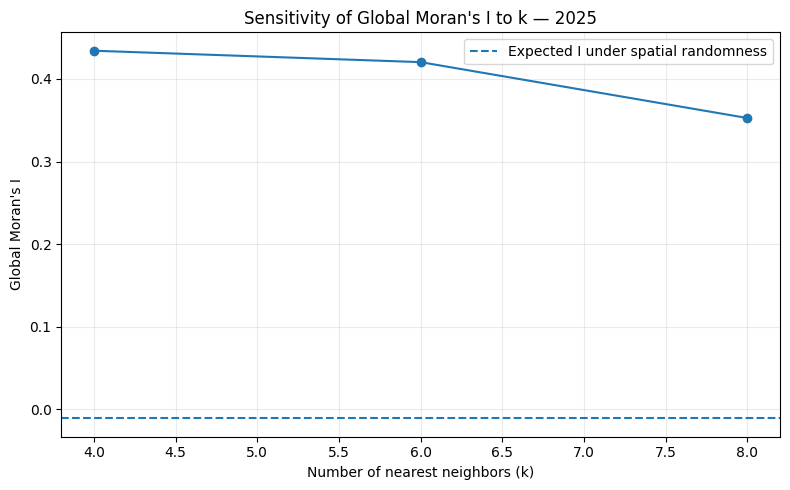

In [14]:
# CELL 14 — Moran's I sensitivity plot

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.plot(
    knn_sensitivity[
        "k"
    ],
    knn_sensitivity[
        "moran_I"
    ],
    marker="o",
)

ax.axhline(
    knn_sensitivity[
        "expected_I"
    ].mean(),
    linestyle="--",
    label="Expected I under spatial randomness",
)

ax.set_xlabel(
    "Number of nearest neighbors (k)"
)

ax.set_ylabel(
    "Global Moran's I"
)

ax.set_title(
    (
        f"Sensitivity of Global Moran's I to k — "
        f"{ANALYSIS_YEAR}"
    )
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

K_SENSITIVITY_FIG = (
    FIGURE_DIR
    / (
        f"06_Moran_k_sensitivity_{ANALYSIS_YEAR}.png"
    )
)

fig.savefig(
    K_SENSITIVITY_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 6.12 Select a Primary KNN Model

สำหรับการสอน default:

```text
PRIMARY_K = 6
```

แต่ถ้าจำนวน station น้อยกว่า:

```text
k = min(6, n - 1)
```

เราจะใช้ primary weights สำหรับ:

```text
Moran scatterplot
Local Moran / LISA
```

และยังรายงาน sensitivity table จาก k อื่นประกอบ

In [15]:
# CELL 15 — Primary KNN weights

PRIMARY_K = min(
    PRIMARY_K_REQUESTED,
    len(
        station_ids
    )
    - 1,
)


if PRIMARY_K < 1:

    raise RuntimeError(
        "Not enough stations for spatial weights."
    )


if PRIMARY_K in knn_weights:

    w_primary = (
        knn_weights[
            PRIMARY_K
        ]
    )

else:

    w_primary, _ = (
        build_knn_w(
            ids=
                station_ids,

            distance_matrix=
                distance_matrix_km,

            k=
                PRIMARY_K,
        )
    )


primary_weights_summary = pd.DataFrame([
    weights_summary(
        w_primary,
        f"KNN k={PRIMARY_K}",
    )
])


display(
    primary_weights_summary
)

,weights,n,islands_n,neighbors_min,neighbors_mean,neighbors_median,neighbors_max,pct_nonzero
0,KNN k=6,94,0,6.0,6.0,6.0,6.0,6.382979


In [16]:
# CELL 16 — Neighbor counts for each station

neighbor_count_table = pd.DataFrame({
    "station_id":
        station_ids,

    "neighbor_n":
        [
            w_primary.cardinalities[
                station_id
            ]
            for station_id
            in station_ids
        ],
})


neighbor_count_table = (
    neighbor_count_table
    .merge(
        analysis_wgs84[
            [
                c
                for c
                in [
                    "station_id",
                    "station_name_en",
                    "province_name_en",
                    VARIABLE,
                    "calendar_year_coverage_pct",
                ]
                if c
                in analysis_wgs84.columns
            ]
        ],
        on="station_id",
        how="left",
        validate="one_to_one",
    )
)


display(
    neighbor_count_table.head(
        20
    )
)

,station_id,neighbor_n,station_name_en,province_name_en,mean_pm25,calendar_year_coverage_pct
0,02t,6,Bansomdejchaopraya Rajabhat University,Bangkok,22.784211,98.904110
1,03t,6,Highway NO.3902 km.13 +600,Bangkok,24.953463,98.904110
2,05t,6,Thai Meteorological Department,Bangkok,21.342577,97.808219
3,08t,6,Prabadang Rehabiltation Center,Samut Prakan,26.129296,97.260274
4,100t,6,Chanthaburi Meteorological Station,Chanthaburi,15.581370,100.000000
5,101t,6,Buriram City Hall,Buri Ram,17.405655,92.054795
6,102t,6,Mukdahan Provincial Stadium,Mukdahan,21.717906,99.452055
7,103t,6,Hua Hin Weather Station Prachuap Khiri Khan Me...,Prachuap Khiri Khan,17.212603,100.000000
8,104t,6,SINGBURI SCHOOL,Sing Buri,26.400829,99.178082
9,105t,6,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,15.477747,99.726027


# 6.13 Global Moran's I

Conceptual form:

\[
I =
\frac{n}{S_0}
\frac{
\sum_i \sum_j
w_{ij}
(x_i-\bar{x})
(x_j-\bar{x})
}{
\sum_i
(x_i-\bar{x})^2
}
\]

ไม่จำเป็นต้องท่องสูตร

แต่ต้องเข้าใจ:

```text
value at i
×
neighbor value at j
×
spatial weight
```

---

# Interpretation แบบง่าย

```text
I > expected I
→ tendency toward positive spatial autocorrelation

I < expected I
→ tendency toward negative spatial autocorrelation
```

แต่ต้องดู permutation p-value ด้วย

In [17]:
# CELL 17 — Primary Global Moran's I

np.random.seed(
    RANDOM_SEED
)


global_moran = Moran(
    y,
    w_primary,
    permutations=
        PERMUTATIONS,
    two_tailed=
        True,
)


global_moran_result = pd.DataFrame([
    {
        "analysis_year":
            ANALYSIS_YEAR,

        "variable":
            VARIABLE,

        "station_n":
            len(
                analysis_wgs84
            ),

        "weights":
            f"KNN k={PRIMARY_K}",

        "moran_I":
            global_moran.I,

        "expected_I":
            global_moran.EI,

        "z_sim":
            global_moran.z_sim,

        "p_sim":
            global_moran.p_sim,

        "permutations":
            PERMUTATIONS,

        "alpha":
            ALPHA,

        "significant_at_alpha":
            (
                global_moran.p_sim
                < ALPHA
            ),
    }
])


display(
    global_moran_result
)

,analysis_year,variable,station_n,weights,moran_I,expected_I,z_sim,p_sim,permutations,alpha,significant_at_alpha
0,2025,mean_pm25,94,KNN k=6,0.42036,-0.010753,8.383052,0.001,999,0.05,True


# Permutation Test

Permutation test สลับค่าระหว่าง locations หลายครั้ง:

```text
Observed pattern
vs
patterns under spatial randomness
```

Notebook ใช้:

```text
999 permutations
```

`p_sim` คือ pseudo p-value จาก permutation distribution

---

# ข้อควรระวัง

```text
p < 0.05
```

ไม่ได้บอกว่า effect มีขนาดใหญ่

และ:

```text
p >= 0.05
```

ไม่ได้พิสูจน์ว่าไม่มี spatial process

ผลขึ้นกับ:

```text
sample size
weights
network geometry
measurement variability
```

# 6.14 Moran Scatterplot

แกน X:

```text
standardized PM2.5
```

แกน Y:

```text
spatial lag of standardized PM2.5
```

quadrants:

```text
High–High
Low–Low
High–Low
Low–High
```

Moran scatterplot เป็น exploratory diagnostic
ไม่ใช่ local significance test

In [18]:
# CELL 18 — Standardize PM2.5 and compute spatial lag

y_mean = np.mean(
    y
)

y_std = np.std(
    y,
    ddof=0,
)


if (
    not np.isfinite(
        y_std
    )
    or y_std
    == 0
):

    raise RuntimeError(
        "PM2.5 has zero or invalid variance; "
        "Moran's I cannot be meaningfully computed."
    )


z_pm25 = (
    y
    - y_mean
) / y_std


lag_z_pm25 = lag_spatial(
    w_primary,
    z_pm25,
)


moran_scatter_table = pd.DataFrame({
    "station_id":
        station_ids,

    "z_pm25":
        z_pm25,

    "spatial_lag_z_pm25":
        lag_z_pm25,
})


display(
    moran_scatter_table.head(
        15
    )
)

,station_id,z_pm25,spatial_lag_z_pm25
0,02t,0.276479,0.368172
1,03t,0.729568,0.491935
2,05t,-0.024634,0.412308
3,08t,0.975163,0.245676
4,100t,-1.227971,0.007426
5,101t,-0.846935,-0.029878
6,102t,0.053761,0.348234
7,103t,-0.887257,0.785054
8,104t,1.031878,0.383672
9,105t,-1.249615,0.620222


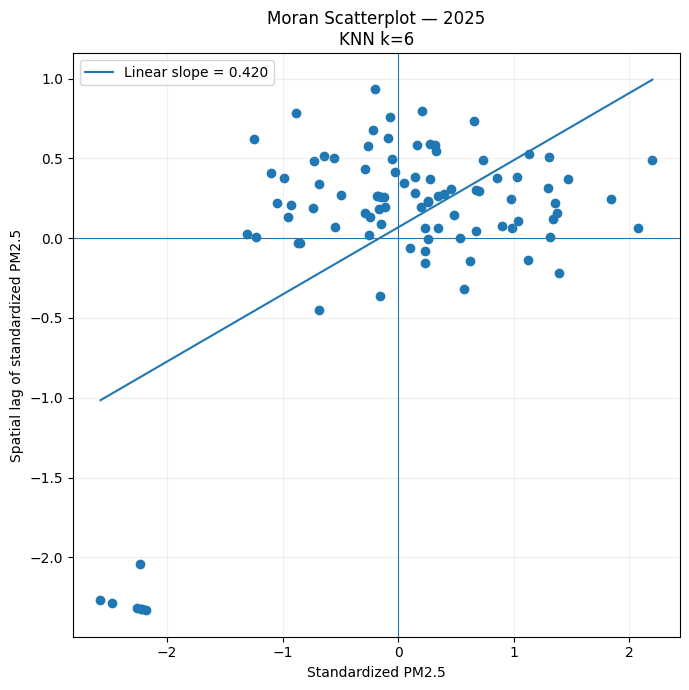

In [19]:
# CELL 19 — Moran scatterplot

slope, intercept = np.polyfit(
    z_pm25,
    lag_z_pm25,
    1,
)


x_line = np.linspace(
    z_pm25.min(),
    z_pm25.max(),
    100,
)


y_line = (
    slope
    * x_line
    + intercept
)


fig, ax = plt.subplots(
    figsize=(
        7,
        7,
    )
)

ax.scatter(
    z_pm25,
    lag_z_pm25,
)

ax.plot(
    x_line,
    y_line,
    label=(
        f"Linear slope = {slope:.3f}"
    ),
)

ax.axhline(
    0,
    linewidth=0.8,
)

ax.axvline(
    0,
    linewidth=0.8,
)

ax.set_xlabel(
    "Standardized PM2.5"
)

ax.set_ylabel(
    "Spatial lag of standardized PM2.5"
)

ax.set_title(
    (
        f"Moran Scatterplot — {ANALYSIS_YEAR}\n"
        f"KNN k={PRIMARY_K}"
    )
)

ax.grid(
    alpha=0.2
)

ax.legend()

fig.tight_layout()

MORAN_SCATTER_FIG = (
    FIGURE_DIR
    / (
        f"06_Moran_scatter_{ANALYSIS_YEAR}.png"
    )
)

fig.savefig(
    MORAN_SCATTER_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 6.15 Local Moran / LISA

Global Moran ถาม:

> ทั้ง network มี spatial autocorrelation หรือไม่?

Local Moran ถาม:

> station ใดมี local spatial association แบบใด?

ประเภท:

```text
HH = High surrounded by High
LL = Low surrounded by Low
HL = High surrounded by Low
LH = Low surrounded by High
```

---

# สำคัญมาก

HH/LL จะเรียกว่า local cluster อย่างมีนัยสำคัญ
เมื่อ local permutation test รองรับ

ไม่ใช่เพียงอยู่ใน quadrant นั้น

In [20]:
# CELL 20 — Local Moran statistics

local_moran = Moran_Local(
    y,
    w_primary,
    permutations=
        PERMUTATIONS,
    seed=
        RANDOM_SEED,
)


local_result = (
    analysis_wgs84[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "province_name_en",
                "latitude",
                "longitude",
                VARIABLE,
                "calendar_year_coverage_pct",
                "geometry",
            ]
            if c
            in analysis_wgs84.columns
        ]
    ]
    .copy()
)


local_result[
    "z_pm25"
] = z_pm25

local_result[
    "lag_z_pm25"
] = lag_z_pm25

local_result[
    "local_moran_I"
] = (
    local_moran.Is
)

local_result[
    "local_p_sim"
] = (
    local_moran.p_sim
)

In [21]:
# CELL 21 — Transparent quadrant classification

def lisa_quadrant(
    z_value,
    lag_value,
):
    if (
        z_value >= 0
        and lag_value >= 0
    ):
        return "HH"

    if (
        z_value < 0
        and lag_value < 0
    ):
        return "LL"

    if (
        z_value >= 0
        and lag_value < 0
    ):
        return "HL"

    return "LH"


local_result[
    "lisa_quadrant"
] = [
    lisa_quadrant(
        z_value,
        lag_value,
    )
    for z_value, lag_value
    in zip(
        local_result[
            "z_pm25"
        ],
        local_result[
            "lag_z_pm25"
        ],
    )
]


local_result[
    "local_significant_raw"
] = (
    local_result[
        "local_p_sim"
    ]
    < ALPHA
)


local_result[
    "lisa_raw"
] = np.where(
    local_result[
        "local_significant_raw"
    ],
    local_result[
        "lisa_quadrant"
    ],
    "Not significant",
)


display(
    local_result[
        [
            c
            for c
            in [
                "station_id",
                "station_name_en",
                "province_name_en",
                VARIABLE,
                "z_pm25",
                "lag_z_pm25",
                "local_moran_I",
                "local_p_sim",
                "lisa_quadrant",
                "lisa_raw",
            ]
            if c
            in local_result.columns
        ]
    ]
    .sort_values(
        "local_p_sim"
    )
    .head(
        30
    )
)

,station_id,station_name_en,province_name_en,mean_pm25,z_pm25,lag_z_pm25,local_moran_I,local_p_sim,lisa_quadrant,lisa_raw
48,43t,Municipal Health Center,Phuket,10.860000,-2.214119,-2.326614,5.096598,0.001,LL,LL
49,44t,Hat Yai Municipality,Songkhla,10.991117,-2.186733,-2.331178,5.043433,0.001,LL,LL
47,42t,"Environment Agency Section 14, Surat Thani",Surat Thani,10.762534,-2.234477,-2.041515,4.513189,0.001,LL,LL
74,80t,"City Hall, Satun",Satun,10.806849,-2.225221,-2.324764,5.118079,0.001,LL,LL
83,89t,Elderly Health Rehabilitation Center,Nakhon Si Thammarat,10.640822,-2.259899,-2.318984,5.184917,0.001,LL,LL
87,93t,"Polytechnic College, Trang",Trang,9.606849,-2.475863,-2.282990,5.592239,0.001,LL,LL
72,78t,"child development centers, Betong",Yala,9.120286,-2.577491,-2.266052,5.778594,0.001,LL,LL
78,84t,Samut Songkhram Health Office,Samut Songkhram,20.483562,-0.204055,0.937050,-0.189176,0.013,LH,LH
7,103t,Hua Hin Weather Station Prachuap Khiri Khan Me...,Prachuap Khiri Khan,17.212603,-0.887257,0.785054,-0.689135,0.019,LH,LH
17,113t,Bueng Planchai,Roi Et,21.110585,-0.073090,0.760093,-0.054964,0.022,LH,LH


# 6.16 Multiple Testing Problem in LISA

ถ้ามี 100 stations
และเราทดสอบ:

```text
100 local hypotheses
```

ด้วย:

```text
alpha = 0.05
```

บาง station อาจดู significant จาก chance เพียงอย่างเดียว

ดังนั้น local tests มี **multiple-testing problem**

---

# Benjamini–Hochberg False Discovery Rate

Notebook จะเพิ่ม FDR-adjusted p-values

กำหนด:

```text
FDR q = 0.05
```

นี่เข้มกว่าการใช้ raw local p-values โดยตรง
และช่วยลด false discoveries

แต่ไม่ใช่วิธีเดียวที่เป็นไปได้

In [22]:
# CELL 22 — Benjamini-Hochberg FDR helper

def benjamini_hochberg(
    p_values,
):
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    m = len(
        p_values
    )

    order = np.argsort(
        p_values
    )

    ranked_p = p_values[
        order
    ]

    ranks = np.arange(
        1,
        m + 1,
    )


    adjusted_ranked = (
        ranked_p
        * m
        / ranks
    )


    adjusted_ranked = np.minimum.accumulate(
        adjusted_ranked[
            ::-1
        ]
    )[
        ::-1
    ]


    adjusted_ranked = np.clip(
        adjusted_ranked,
        0,
        1,
    )


    adjusted = np.empty(
        m,
        dtype=float,
    )

    adjusted[
        order
    ] = adjusted_ranked


    return adjusted

In [23]:
# CELL 23 — Apply FDR correction

local_result[
    "local_p_fdr_bh"
] = (
    benjamini_hochberg(
        local_result[
            "local_p_sim"
        ]
        .to_numpy(
            dtype=float
        )
    )
)


local_result[
    "local_significant_fdr"
] = (
    local_result[
        "local_p_fdr_bh"
    ]
    < FDR_Q
)


local_result[
    "lisa_fdr"
] = np.where(
    local_result[
        "local_significant_fdr"
    ],
    local_result[
        "lisa_quadrant"
    ],
    "Not significant",
)


fdr_comparison = pd.DataFrame([
    {
        "criterion":
            "Raw local p < 0.05",

        "significant_station_n":
            int(
                local_result[
                    "local_significant_raw"
                ]
                .sum()
            ),
    },

    {
        "criterion":
            "Benjamini-Hochberg FDR < 0.05",

        "significant_station_n":
            int(
                local_result[
                    "local_significant_fdr"
                ]
                .sum()
            ),
    },
])


display(
    fdr_comparison
)

,criterion,significant_station_n
0,Raw local p < 0.05,13
1,Benjamini-Hochberg FDR < 0.05,7


In [24]:
# CELL 24 — LISA category counts after FDR

lisa_fdr_counts = (
    local_result[
        "lisa_fdr"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "lisa_class"
    )
    .reset_index(
        name="station_n"
    )
)


display(
    lisa_fdr_counts
)

,lisa_class,station_n
0,Not significant,87
1,LL,7


# 6.17 LISA Station Map

แผนที่นี้แสดง:

```text
local spatial association
at monitoring stations
```

ไม่ใช่:

```text
continuous hotspot zones
```

พื้นที่ระหว่าง station ไม่มี LISA value โดยตรง

ดังนั้นชื่อที่เหมาะสมคือ:

> LISA classification of monitoring stations

ไม่ใช่:

> PM₂.₅ hotspot surface of Thailand

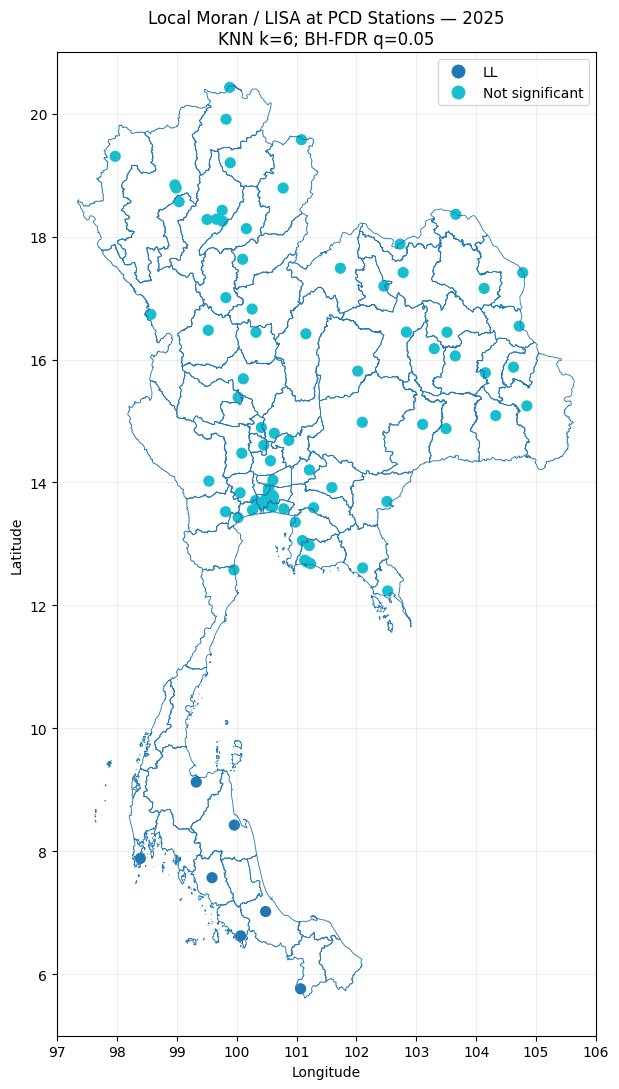

In [25]:
# CELL 25 — LISA station map after FDR correction

local_result_gdf = gpd.GeoDataFrame(
    local_result,
    geometry="geometry",
    crs=analysis_wgs84.crs,
)


fig, ax = plt.subplots(
    figsize=(
        8.5,
        11,
    )
)

province.boundary.plot(
    ax=ax,
    linewidth=0.6,
)

local_result_gdf.plot(
    ax=ax,
    column="lisa_fdr",
    categorical=True,
    legend=True,
    markersize=50,
)

ax.set_xlim(
    97,
    106,
)

ax.set_ylim(
    5,
    21,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    (
        f"Local Moran / LISA at PCD Stations — "
        f"{ANALYSIS_YEAR}\n"
        f"KNN k={PRIMARY_K}; BH-FDR q={FDR_Q}"
    )
)

ax.grid(
    alpha=0.2
)

fig.tight_layout()

LISA_MAP = (
    FIGURE_DIR
    / (
        f"06_LISA_FDR_{ANALYSIS_YEAR}.png"
    )
)

fig.savefig(
    LISA_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 6.18 Alternative Weights — Distance Band

KNN กำหนด:

```text
ทุก station มีจำนวน neighbors ใกล้เคียงกัน
```

Distance band กำหนด:

```text
ทุก station ภายในระยะ threshold เป็น neighbor
```

---

# Auto Threshold for Teaching

เราจะใช้:

```text
threshold
=
maximum nearest-neighbor distance
× 1.001
```

เหตุผล:

> ให้ทุก station มีอย่างน้อย 1 neighbor

แต่ถ้ามี isolated station อยู่ไกลมาก
threshold อาจใหญ่และ graph อาจ dense เกินไป

ดังนั้นต้องรายงาน neighbor counts และ network density

In [26]:
# CELL 26 — Build distance-band weights

minimum_connecting_threshold_km = (
    nearest_distances.max()
    * 1.001
)


w_distance_band = (
    build_distance_band_w(
        ids=
            station_ids,

        distance_matrix=
            distance_matrix_km,

        threshold_km=
            minimum_connecting_threshold_km,
    )
)


distance_band_summary = pd.DataFrame([
    {
        **weights_summary(
            w_distance_band,
            (
                "Distance band "
                f"<= {minimum_connecting_threshold_km:.2f} km"
            ),
        ),

        "threshold_km":
            minimum_connecting_threshold_km,
    }
])


display(
    distance_band_summary
)

,weights,n,islands_n,neighbors_min,neighbors_mean,neighbors_median,neighbors_max,pct_nonzero,threshold_km
0,Distance band <= 146.52 km,94,0,1.0,18.659574,10.0,40.0,19.850611,146.522876


In [27]:
# CELL 27 — Global Moran with distance-band weights

np.random.seed(
    RANDOM_SEED
)


moran_distance_band = Moran(
    y,
    w_distance_band,
    permutations=
        PERMUTATIONS,
    two_tailed=
        True,
)


weights_method_comparison = pd.DataFrame([
    {
        "weights_method":
            f"KNN k={PRIMARY_K}",

        "moran_I":
            global_moran.I,

        "expected_I":
            global_moran.EI,

        "p_sim":
            global_moran.p_sim,

        "neighbors_mean":
            primary_weights_summary[
                "neighbors_mean"
            ].iloc[
                0
            ],

        "islands_n":
            primary_weights_summary[
                "islands_n"
            ].iloc[
                0
            ],
    },

    {
        "weights_method":
            (
                "Distance band "
                f"{minimum_connecting_threshold_km:.2f} km"
            ),

        "moran_I":
            moran_distance_band.I,

        "expected_I":
            moran_distance_band.EI,

        "p_sim":
            moran_distance_band.p_sim,

        "neighbors_mean":
            distance_band_summary[
                "neighbors_mean"
            ].iloc[
                0
            ],

        "islands_n":
            distance_band_summary[
                "islands_n"
            ].iloc[
                0
            ],
    },
])


display(
    weights_method_comparison
)

,weights_method,moran_I,expected_I,p_sim,neighbors_mean,islands_n
0,KNN k=6,0.420360,-0.010753,0.001,6.000000,0
1,Distance band 146.52 km,0.439167,-0.010753,0.001,18.659574,0


# Interpretation of Weight Sensitivity

ถ้า:

```text
KNN
และ
Distance Band
```

ให้ผลคล้ายกัน:

> inference มีความ robust ต่อ weights definition มากขึ้น

ถ้าผลแตกต่างกันมาก:

> spatial conclusion มี sensitivity ต่อ neighborhood model

ควรรายงานทั้งสองแทนการเลือกเฉพาะผลที่ significant

In [28]:
# CELL 28 — Distance-band neighbor counts

distance_band_neighbor_table = pd.DataFrame({
    "station_id":
        station_ids,

    "distance_band_neighbor_n":
        [
            w_distance_band.cardinalities[
                station_id
            ]
            for station_id
            in station_ids
        ],
})


distance_band_neighbor_table = (
    distance_band_neighbor_table
    .merge(
        neighbor_count_table[
            [
                "station_id",
                "neighbor_n",
            ]
        ]
        .rename(
            columns={
                "neighbor_n":
                    "knn_neighbor_n"
            }
        ),
        on="station_id",
        how="left",
        validate="one_to_one",
    )
)


display(
    distance_band_neighbor_table.sort_values(
        "distance_band_neighbor_n"
    )
)

,station_id,distance_band_neighbor_n,knn_neighbor_n
48,43t,1,6
47,42t,1,6
81,87t,1,6
72,78t,1,6
67,73t,2,6
...,...,...,...
2,05t,40,6
1,03t,40,6
0,02t,40,6
21,12t,40,6


# 6.19 Mini Research

ตอนนี้นิสิตมีองค์ประกอบครบ:

```text
Research question
Data
QC
Temporal aggregation
Geometry
Spatial weights
Global statistic
Local statistic
Sensitivity analysis
Interpretation
Limitations
```

เราจะปิด course ด้วย mini research template

# Mini Research Question

## ตัวอย่างคำถาม

> ในปีที่มี coverage-eligible monitoring stations มากที่สุด ค่าเฉลี่ย PM₂.₅ รายสถานีของประเทศไทยมี spatial autocorrelation หรือไม่ และมี local station clusters แบบ HH/LL หรือ spatial outliers แบบ HL/LH ที่ใด?

---

# Hypotheses

## Global Moran

\[
H_0:
\]

ไม่มี spatial autocorrelation ภายใต้ spatial-randomization framework

\[
H_A:
\]

มี spatial autocorrelation

---

# Local Moran

ใช้เพื่อระบุ local patterns:

```text
HH
LL
HL
LH
```

แต่ต้องใช้ multiple-testing correction ประกอบ

In [29]:
# CELL 29 — Automated mini-research result summary

global_interpretation = (
    "statistically significant"
    if global_moran.p_sim
    < ALPHA
    else "not statistically significant"
)


direction_interpretation = (
    "positive"
    if global_moran.I
    > global_moran.EI
    else "negative"
)


significant_fdr_n = int(
    local_result[
        "local_significant_fdr"
    ]
    .sum()
)


mini_research_summary = f"""
MINI RESEARCH SUMMARY
=====================

Analysis year
-------------
{ANALYSIS_YEAR}

Variable
--------
{VARIABLE}

Spatial observations
--------------------
{len(analysis_points)} monitoring stations

Completeness criterion
----------------------
Calendar-year coverage >= {MIN_COVERAGE_PCT:.1f}%

Primary spatial weights
-----------------------
K-nearest neighbors, k = {PRIMARY_K}
Row standardized

Global Moran's I
----------------
Observed I  = {global_moran.I:.6f}
Expected I  = {global_moran.EI:.6f}
Permutation p = {global_moran.p_sim:.6f}
Permutations = {PERMUTATIONS}

Interpretation
--------------
The observed Moran's I is {direction_interpretation}
relative to the expected value under spatial randomness,
and the permutation result is {global_interpretation}
at alpha = {ALPHA:.2f}.

Local Moran / LISA
------------------
Raw local p < {ALPHA:.2f}:
{int(local_result["local_significant_raw"].sum())} stations

BH-FDR q < {FDR_Q:.2f}:
{significant_fdr_n} stations

Sensitivity
-----------
K values tested:
{unique_k_values}

Distance-band threshold:
{minimum_connecting_threshold_km:.3f} km

Scientific caution
------------------
These results describe spatial association among monitoring
stations for one temporal slice. They do not represent a
continuous PM2.5 surface and do not identify emission sources
or causal mechanisms.
""".strip()


print(
    mini_research_summary
)

MINI RESEARCH SUMMARY

Analysis year
-------------
2025

Variable
--------
mean_pm25

Spatial observations
--------------------
94 monitoring stations

Completeness criterion
----------------------
Calendar-year coverage >= 75.0%

Primary spatial weights
-----------------------
K-nearest neighbors, k = 6
Row standardized

Global Moran's I
----------------
Observed I  = 0.420360
Expected I  = -0.010753
Permutation p = 0.001000
Permutations = 999

Interpretation
--------------
The observed Moran's I is positive
relative to the expected value under spatial randomness,
and the permutation result is statistically significant
at alpha = 0.05.

Local Moran / LISA
------------------
Raw local p < 0.05:
13 stations

BH-FDR q < 0.05:
7 stations

Sensitivity
-----------
K values tested:
[4, 6, 8]

Distance-band threshold:
146.523 km

Scientific caution
------------------
These results describe spatial association among monitoring
stations for one temporal slice. They do not represent a
continuous

# 6.20 Limitations to Report in a Paper or Thesis

อย่างน้อยควรกล่าวถึง:

## 1. Uneven monitoring-network density

PCD stations ไม่ได้กระจายแบบ regular grid

จึงมีพื้นที่:

```text
dense network
sparse network
```

---

## 2. Station representativeness

แต่ละ station เป็น point observation

อาจสะท้อน:

```text
urban
traffic
industrial
background
regional
```

แตกต่างกัน

---

## 3. Spatial weights sensitivity

ผลขึ้นกับ:

```text
KNN k
distance threshold
row standardization
```

---

## 4. Temporal aggregation

station-year mean ลด temporal variability

แต่ช่วยให้:

```text
หนึ่ง station = หนึ่ง spatial observation
```

---

## 5. Five-year teaching period

การวิเคราะห์ปีเดียวจาก 2021–2025
ไม่ใช่ long-term climatological inference

---

## 6. Local multiple testing

LISA หลาย location มี false-positive risk

จึงใช้ FDR correction

---

## 7. Spatial association ≠ source attribution

HH cluster ไม่ได้แปลว่า:

> emission source อยู่ตรงนั้น

ต้องใช้ข้อมูลเพิ่มเติม เช่น:

```text
emission inventory
fire hotspots
wind
trajectory
meteorology
land use
topography
satellite aerosol
```

# 6.21 Optional Three-Province Mini Research Check

Course นี้ใช้:

```text
Saraburi
Lop Buri
Nakhon Nayok
```

เป็นกรณีศึกษาต่อเนื่อง

แต่ spatial statistics ต้องมี sample size ที่พอสมควร

ดังนั้น Notebook จะตรวจจำนวน coverage-eligible stations ใน 3 จังหวัดก่อน

หากน้อยเกินไป:

> ไม่ควรฝืนคำนวณ Moran's I เพียงเพราะ code ทำได้

การตัดสินว่า sample ไม่เพียงพอ
เป็นส่วนหนึ่งของ scientific method

In [30]:
# CELL 30 — Count eligible stations in the three-province case

CASE_PROVINCE_KEYS = {
    "saraburi",
    "lop buri",
    "lopburi",
    "nakhon nayok",
    "nakhonnayok",
}


def normalize_place_name(
    value,
):
    if pd.isna(
        value
    ):
        return None

    return " ".join(
        str(
            value
        )
        .strip()
        .lower()
        .split()
    )


analysis_points[
    "_province_norm"
] = (
    analysis_points[
        "province_name_en"
    ]
    .map(
        normalize_place_name
    )
)


case_three_provinces = (
    analysis_points[
        analysis_points[
            "_province_norm"
        ]
        .isin(
            CASE_PROVINCE_KEYS
        )
    ]
    .copy()
)


MIN_STATIONS_FOR_CASE_MORAN = 8


print(
    "Three-province stations:",
    len(
        case_three_provinces
    )
)


if len(
    case_three_provinces
) >= MIN_STATIONS_FOR_CASE_MORAN:

    print(
        "Sample size is sufficient for a teaching exercise, "
        "although inference remains limited."
    )

else:

    print(
        "Sample size is too small for a defensible "
        "three-province Moran's I exercise."
    )

    print(
        "Use descriptive mapping/statistics instead, "
        "or expand the spatial domain."
    )

Three-province stations: 3
Sample size is too small for a defensible three-province Moran's I exercise.
Use descriptive mapping/statistics instead, or expand the spatial domain.


# 6.22 Save Reproducible Outputs

CSV:

```text
06_analysis_QC.csv
06_analysis_points.csv
06_KNN_sensitivity.csv
06_primary_weights_summary.csv
06_neighbor_counts.csv
06_global_Moran.csv
06_Moran_scatter_values.csv
06_LISA_results.csv
06_LISA_FDR_counts.csv
06_FDR_comparison.csv
06_distance_band_summary.csv
06_distance_band_neighbor_counts.csv
06_weights_method_comparison.csv
06_three_province_sample_check.csv
```

GeoPackage:

```text
06_spatial_statistics.gpkg
```

layers:

```text
analysis_points
lisa_points
```

Text:

```text
06_mini_research_summary.txt
```

In [31]:
# CELL 31 — Save CSV outputs

three_province_sample_check = pd.DataFrame([
    {
        "analysis_year":
            ANALYSIS_YEAR,

        "station_n":
            len(
                case_three_provinces
            ),

        "minimum_recommended_for_teaching":
            MIN_STATIONS_FOR_CASE_MORAN,

        "status":
            (
                "TEACHING_ANALYSIS_POSSIBLE"
                if len(
                    case_three_provinces
                )
                >= MIN_STATIONS_FOR_CASE_MORAN
                else "DESCRIPTIVE_ONLY_RECOMMENDED"
            ),
    }
])


CSV_OUTPUTS = {
    "06_analysis_QC.csv":
        analysis_qc,

    "06_analysis_points.csv":
        analysis_wgs84.drop(
            columns="geometry",
            errors="ignore",
        ),

    "06_KNN_sensitivity.csv":
        knn_sensitivity,

    "06_primary_weights_summary.csv":
        primary_weights_summary,

    "06_neighbor_counts.csv":
        neighbor_count_table,

    "06_global_Moran.csv":
        global_moran_result,

    "06_Moran_scatter_values.csv":
        moran_scatter_table,

    "06_LISA_results.csv":
        local_result_gdf.drop(
            columns="geometry",
            errors="ignore",
        ),

    "06_LISA_FDR_counts.csv":
        lisa_fdr_counts,

    "06_FDR_comparison.csv":
        fdr_comparison,

    "06_distance_band_summary.csv":
        distance_band_summary,

    "06_distance_band_neighbor_counts.csv":
        distance_band_neighbor_table,

    "06_weights_method_comparison.csv":
        weights_method_comparison,

    "06_three_province_sample_check.csv":
        three_province_sample_check,
}


for filename, table in CSV_OUTPUTS.items():

    path = (
        OUTPUT_DIR
        / filename
    )

    table.to_csv(
        path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        "Saved:",
        filename
    )

Saved: 06_analysis_QC.csv
Saved: 06_analysis_points.csv
Saved: 06_KNN_sensitivity.csv
Saved: 06_primary_weights_summary.csv
Saved: 06_neighbor_counts.csv
Saved: 06_global_Moran.csv
Saved: 06_Moran_scatter_values.csv
Saved: 06_LISA_results.csv
Saved: 06_LISA_FDR_counts.csv
Saved: 06_FDR_comparison.csv
Saved: 06_distance_band_summary.csv
Saved: 06_distance_band_neighbor_counts.csv
Saved: 06_weights_method_comparison.csv
Saved: 06_three_province_sample_check.csv


In [32]:
# CELL 32 — Save GeoPackage

SPATIAL_STATS_GPKG = (
    OUTPUT_DIR
    / "06_spatial_statistics.gpkg"
)


if SPATIAL_STATS_GPKG.exists():

    SPATIAL_STATS_GPKG.unlink()


analysis_wgs84.to_file(
    SPATIAL_STATS_GPKG,
    layer="analysis_points",
    driver="GPKG",
)


local_result_gdf.to_file(
    SPATIAL_STATS_GPKG,
    layer="lisa_points",
    driver="GPKG",
    mode="a",
)


print(
    "Saved:",
    SPATIAL_STATS_GPKG
)

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_06/06_spatial_statistics.gpkg


In [33]:
# CELL 33 — Save mini-research summary

MINI_RESEARCH_FILE = (
    OUTPUT_DIR
    / "06_mini_research_summary.txt"
)


MINI_RESEARCH_FILE.write_text(
    mini_research_summary,
    encoding="utf-8",
)


print(
    "Saved:",
    MINI_RESEARCH_FILE
)

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_06/06_mini_research_summary.txt


# 6.23 Final Course Checkpoint

Notebook 06 ถือว่าผ่าน core workflow เมื่อ:

```text
one temporal slice created
geodesic distance matrix created
KNN weights created
k sensitivity completed
Global Moran completed
Local Moran completed
FDR correction completed
distance-band comparison completed
outputs saved
```

ผล Moran's I **ไม่จำเป็นต้อง significant**

เพราะ:

> scientific success = วิเคราะห์ถูกวิธีและตีความถูกต้อง

ไม่ใช่:

> ต้องได้ p < 0.05

In [34]:
# CELL 34 — Final Notebook 06 checkpoint

slice_ready = (
    len(
        analysis_points
    ) >= 2
)


knn_ready = (
    len(
        knn_sensitivity
    ) > 0
)


global_ready = (
    np.isfinite(
        global_moran.I
    )
)


local_ready = (
    len(
        local_result_gdf
    )
    == len(
        analysis_points
    )
)


fdr_ready = (
    local_result_gdf[
        "local_p_fdr_bh"
    ]
    .notna()
    .all()
)


distance_band_ready = (
    len(
        distance_band_summary
    ) == 1
)


outputs_ready = (
    SPATIAL_STATS_GPKG.exists()
    and MINI_RESEARCH_FILE.exists()
)


final_checks = pd.DataFrame([
    {
        "check":
            "Single-year spatial slice",

        "status":
            (
                "PASS"
                if slice_ready
                else "FAIL"
            ),

        "detail":
            (
                f"{ANALYSIS_YEAR}; "
                f"{len(analysis_points)} stations"
            ),
    },

    {
        "check":
            "KNN sensitivity",

        "status":
            (
                "PASS"
                if knn_ready
                else "FAIL"
            ),

        "detail":
            str(
                unique_k_values
            ),
    },

    {
        "check":
            "Global Moran",

        "status":
            (
                "PASS"
                if global_ready
                else "FAIL"
            ),

        "detail":
            (
                f"I={global_moran.I:.4f}; "
                f"p={global_moran.p_sim:.4f}"
            ),
    },

    {
        "check":
            "Local Moran",

        "status":
            (
                "PASS"
                if local_ready
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    local_result_gdf
                )
            ),
    },

    {
        "check":
            "FDR correction",

        "status":
            (
                "PASS"
                if fdr_ready
                else "FAIL"
            ),

        "detail":
            (
                f"{int(local_result_gdf['local_significant_fdr'].sum())} "
                f"significant stations"
            ),
    },

    {
        "check":
            "Distance-band sensitivity",

        "status":
            (
                "PASS"
                if distance_band_ready
                else "FAIL"
            ),

        "detail":
            (
                f"{minimum_connecting_threshold_km:.2f} km"
            ),
    },

    {
        "check":
            "Reproducible outputs",

        "status":
            (
                "PASS"
                if outputs_ready
                else "FAIL"
            ),

        "detail":
            str(
                OUTPUT_DIR
            ),
    },
])


display(
    final_checks
)


if final_checks[
    "status"
].eq(
    "PASS"
).all():

    print(
        "\n======================================"
    )

    print(
        "NOTEBOOK 06 SPATIAL STATISTICS READY"
    )

    print(
        "======================================"
    )

    print(
        "\nCORE COURSE COMPLETE"
    )

else:

    print(
        "\nCHECK NOTEBOOK 06 RESULTS "
        "BEFORE INTERPRETATION"
    )

,check,status,detail
0,Single-year spatial slice,PASS,2025; 94 stations
1,KNN sensitivity,PASS,"[4, 6, 8]"
2,Global Moran,PASS,I=0.4204; p=0.0010
3,Local Moran,PASS,94
4,FDR correction,PASS,7 significant stations
5,Distance-band sensitivity,PASS,146.52 km
6,Reproducible outputs,PASS,/content/drive/MyDrive/Teaching_PCD_Environmen...



NOTEBOOK 06 SPATIAL STATISTICS READY

CORE COURSE COMPLETE


# แบบฝึกหัดท้ายบท

## Exercise 1 — Spatial Autocorrelation

อธิบายด้วยภาษาของตัวเอง:

```text
positive spatial autocorrelation
negative spatial autocorrelation
spatial randomness
```

และยกตัวอย่าง PM₂.₅ อย่างละ 1 ตัวอย่าง

---

## Exercise 2 — Spatial Weights

อธิบายความแตกต่าง:

```text
KNN k=4
KNN k=8
Distance band
```

ตอบว่า:

> spatial neighborhood จะกว้างขึ้นหรือลดลงอย่างไร?

---

## Exercise 3 — Sensitivity to k

จาก:

```text
06_KNN_sensitivity.csv
```

รายงาน:

```text
k
Moran I
expected I
p_sim
```

แล้วตอบ:

> ข้อสรุปเปลี่ยนหรือไม่เมื่อ k เปลี่ยน?

---

## Exercise 4 — Moran Scatterplot

เลือก station จากแต่ละ quadrant:

```text
HH
LL
HL
LH
```

ถ้ามี

อธิบายความหมายเชิง spatial relation

ห้ามเรียกว่า significant cluster จนกว่าจะดู Local Moran p-value

---

## Exercise 5 — Raw LISA vs FDR

เปรียบเทียบจำนวน:

```text
raw p < 0.05
FDR-adjusted p < 0.05
```

แล้วอธิบายว่า:

> ทำไมจำนวน significant stations อาจลดลงหลัง FDR?

---

## Exercise 6 — HH Does Not Mean Source

เลือก HH station 1 แห่ง

เขียนข้อมูลอย่างน้อย 6 ชนิดที่ต้องใช้เพิ่ม
ก่อนจะอภิปราย emission source

---

## Exercise 7 — Distance Band

รายงาน:

```text
threshold_km
minimum neighbors
median neighbors
maximum neighbors
pct_nonzero
```

แล้วตอบ:

> threshold นี้ทำให้ graph dense เกินไปหรือไม่?

---

## Exercise 8 — KNN vs Distance Band

เปรียบเทียบ:

```text
Moran I
p_sim
neighbor structure
```

อภิปรายว่า conclusion robust หรือ sensitive ต่อ weights

---

## Exercise 9 — Three Provinces

ตรวจ:

```text
06_three_province_sample_check.csv
```

ถ้า status เป็น:

```text
DESCRIPTIVE_ONLY_RECOMMENDED
```

อธิบายว่า:

> ทำไม “ไม่ทำ Moran's I” จึงเป็นการตัดสินใจทางวิทยาศาสตร์ที่ถูกต้องได้?

---

## Exercise 10 — Reproducible Mini Research

เขียนผลสั้น ๆ 250–400 คำ ประกอบด้วย:

```text
Research question
Data and year
Completeness criterion
Spatial weights
Global Moran result
LISA/FDR result
Sensitivity
Interpretation
Limitations
```

ห้ามเขียน causal conclusion

# Common Mistakes

## Mistake 1 — เอาทุกปีมารวมเป็น independent spatial points

station เดิมจะซ้ำ location

และเกิด temporal dependence

---

## Mistake 2 — เลือก k หลังเห็นว่าอันไหน significant

เป็น selective inference

ควรกำหนด parameter ล่วงหน้าและรายงาน sensitivity

---

## Mistake 3 — ใช้ LISA raw p-values จำนวนมากโดยไม่พูดถึง multiple testing

ควรพิจารณา correction เช่น FDR

---

## Mistake 4 — HH station = emission source

ไม่จริง

HH หมายถึง:

```text
high value
+
high neighboring values
```

ภายใต้ weights ที่กำหนด

---

## Mistake 5 — LISA station map = continuous hotspot surface

ไม่จริง

เป็น station-level classification

---

## Mistake 6 — p > 0.05 = ไม่มี spatial process

ไม่จำเป็น

อาจเกิดจาก:

```text
small sample
sparse network
wrong weights
high variability
low power
```

---

## Mistake 7 — significant = scientifically important

ต้องพิจารณา:

```text
effect magnitude
robustness
data quality
mechanism
limitations
```

# สรุป Core Course ทั้งหมด

```text
01
Canonical dataset
↓
02
Pandas + PCD PM2.5
↓
03
GeoPandas + CRS + Map literacy
↓
04
Spatial join + Distance + Station matching
↓
05
Spatiotemporal PM2.5 analysis
↓
06
Spatial statistics + Mini research
```

นิสิตได้เรียน workflow ที่นำไปใช้กับข้อมูลสิ่งแวดล้อมอื่นได้ เช่น:

```text
air pollution
water quality
meteorological stations
rain gauges
fire hotspots
health observations
ecological sampling
environmental monitoring
```

---

# Research Workflow ที่ควรจำ

```text
Research Question
        ↓
Source Data
        ↓
Canonical / Reproducible Data
        ↓
QC
        ↓
Temporal Aggregation
        ↓
Geometry + CRS
        ↓
Spatial Relationship
        ↓
Visualization
        ↓
Spatial Statistics
        ↓
Sensitivity Analysis
        ↓
Scientific Interpretation
        ↓
Limitations
        ↓
Reproducible Outputs
```

# Extensions Beyond the Core Course

หัวข้อที่ควรแยกเป็น Notebook ขั้นสูงภายหลัง:

```text
IDW / Kriging
spatial interpolation validation
GWR
spatial regression
spatial panel models
machine learning
satellite aerosol / AOD
fire hotspot integration
ERA5
HYSPLIT trajectories
boundary-layer meteorology
emission inventory
health/mortality analysis
```

หัวข้อเหล่านี้ไม่ควรถูกเพิ่มเข้า Notebook 06 แบบเร่งรีบ
เพราะแต่ละหัวข้อต้องมี methodological assumptions และ validation ของตนเอง